In [19]:
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, LinearRegression
import xgboost as xgb
import matplotlib.pyplot as plt

import openbb as obb
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import norm, skewnorm, t

2000-01-03    6.58
2000-01-04    6.49
2000-01-05    6.62
2000-01-06    6.57
2000-01-07    6.52
              ... 
2025-10-10    4.05
2025-10-13     NaN
2025-10-14    4.03
2025-10-15    4.05
2025-10-16    3.99
Length: 6729, dtype: float64


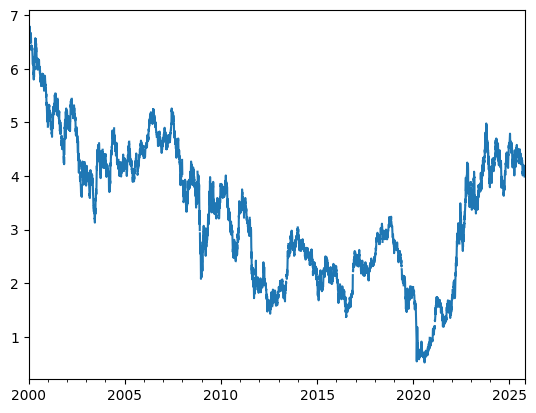

In [20]:
from fredapi import Fred

fred = Fred(api_key='1d66ac86e85e0a552a9c3f463c161295')

# Example: 10-Year Treasury Constant Maturity Rate (DGS10)
yield_10y = fred.get_series('DGS10', observation_start='2000-01-01')
yield_10y.plot()
print(yield_10y)

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['GC=F']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Empty DataFrame
Columns: [GC=F]
Index: []


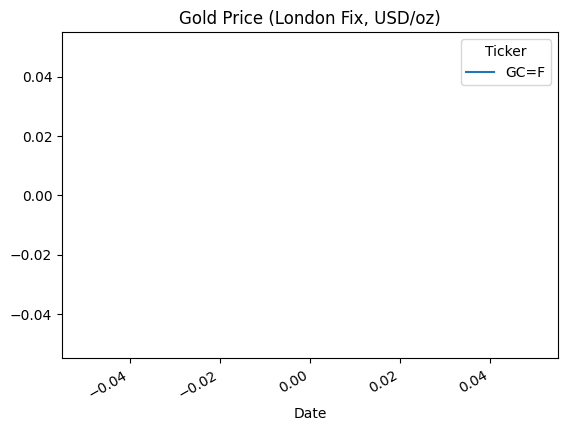

In [21]:
gold = fred.get_series("IR14270")
import yfinance as yf
gold_yahoo = yf.download("GC=F", start="2001-01-01")["Close"]
print(gold_yahoo)


gold_yahoo.plot(title="Gold Price (London Fix, USD/oz)")
plt.show()

            10-Year Treasury Yield
2000-01-03                    6.58
2000-01-04                    6.49
2000-01-05                    6.62
2000-01-06                    6.57
2000-01-07                    6.52
...                            ...
2025-10-10                    4.05
2025-10-13                     NaN
2025-10-14                    4.03
2025-10-15                    4.05
2025-10-16                    3.99

[6729 rows x 1 columns]


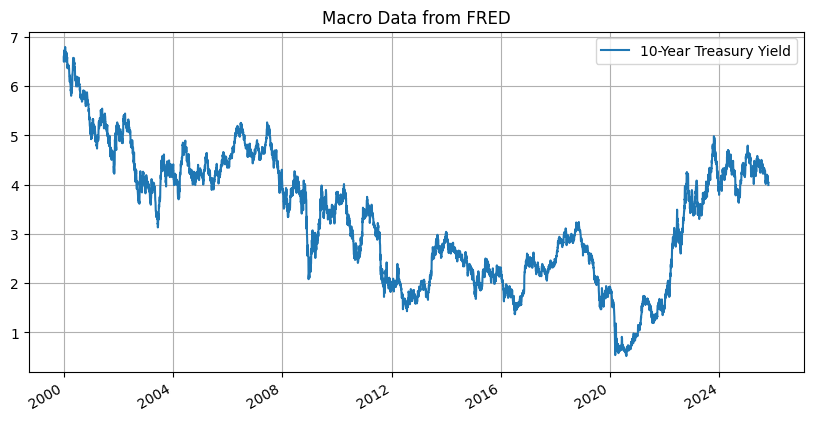

In [22]:
fred = Fred(api_key="1d66ac86e85e0a552a9c3f463c161295")

# Define series of interest
series = {
    #'CPI (Inflation)': 'CPIAUCSL',
    #'Unemployment Rate': 'UNRATE',
    #'GDP (US)': 'GDP',
    #'Fed Funds Rate': 'FEDFUNDS',
    '10-Year Treasury Yield': 'DGS10'
}

# Fetch data
macro_data = pd.DataFrame({name: fred.get_series(id, observation_start='2000-01-01') for name, id in series.items()})

# Plot example: inflation and unemployment
macro_data[[  '10-Year Treasury Yield']].dropna().plot(
    figsize=(10, 5), title="Macro Data from FRED"
)
print(macro_data)

plt.grid(True)
plt.show()

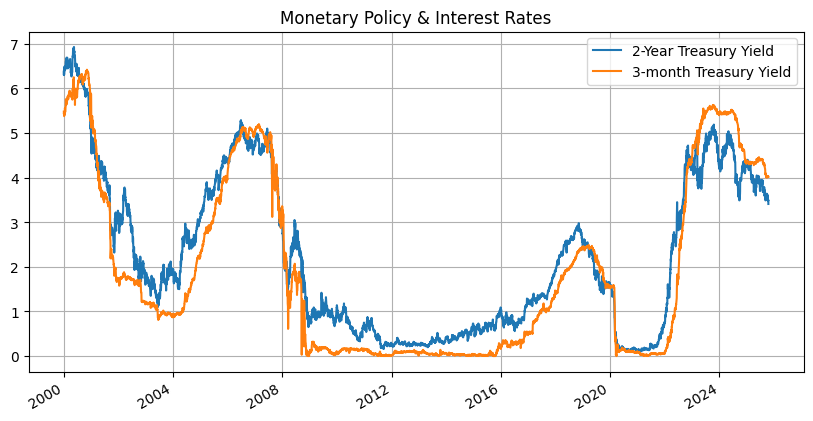

            2-Year Treasury Yield  3-month Treasury Yield
2000-01-03                   6.38                    5.48
2000-01-04                   6.30                    5.43
2000-01-05                   6.38                    5.44
2000-01-06                   6.35                    5.41
2000-01-07                   6.31                    5.38
...                           ...                     ...
2025-10-10                   3.52                    4.02
2025-10-13                    NaN                     NaN
2025-10-14                   3.48                    4.02
2025-10-15                   3.50                    4.03
2025-10-16                   3.41                    4.02

[6729 rows x 2 columns]


In [23]:
fred = Fred(api_key="1d66ac86e85e0a552a9c3f463c161295")

# Define series of interest
series = {
    #'Prime Bank Loan Rate': 'MPRIME',
    #'Discount Rate': 'INTDSRUSM193N',
    '2-Year Treasury Yield': 'DGS2',
    '3-month Treasury Yield': 'DGS3MO',
}

# Fetch data
yield_data = pd.DataFrame({name: fred.get_series(id, observation_start='2000-01-01') for name, id in series.items()})

# Plot example: inflation and unemployment
yield_data.dropna().plot(
    figsize=(10, 5), title="Monetary Policy & Interest Rates"
)
plt.grid(True)
plt.show()
print(yield_data)

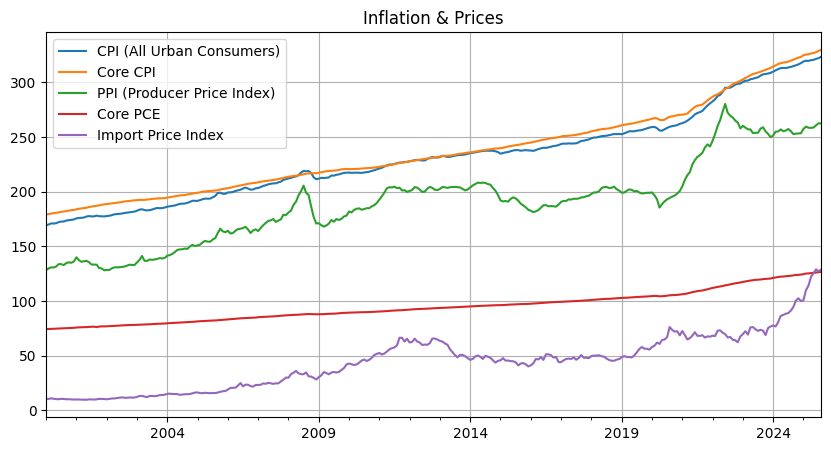

            CPI (All Urban Consumers)  Core CPI  PPI (Producer Price Index)  \
2000-01-01                    169.300   179.300                     128.300   
2000-02-01                    170.000   179.400                     129.800   
2000-03-01                    171.000   180.000                     130.800   
2000-04-01                    170.900   180.300                     130.700   
2000-05-01                    171.200   180.700                     131.600   
...                               ...       ...                         ...   
2025-04-01                    320.321   326.430                     258.392   
2025-05-01                    320.580   326.854                     258.642   
2025-06-01                    321.500   327.600                     260.690   
2025-07-01                    322.132   328.656                     262.562   
2025-08-01                    323.364   329.793                     262.443   

            Core PCE  Import Price Index  
2000-01-

In [24]:
series = {
    'CPI (All Urban Consumers)':	'CPIAUCSL',
'Core CPI':	'CPILFESL',
'PPI (Producer Price Index)':	'PPIACO',
'Core PCE':	'PCEPILFE',
'Import Price Index':	'IR14270',
}
consumer_data = pd.DataFrame({name: fred.get_series(id, observation_start='2000-01-01') for name, id in series.items()})

# Plot example: inflation and unemployment
consumer_data.dropna().plot(
    figsize=(10, 5), title="Inflation & Prices"
)
plt.grid(True)
plt.show()
print(consumer_data)

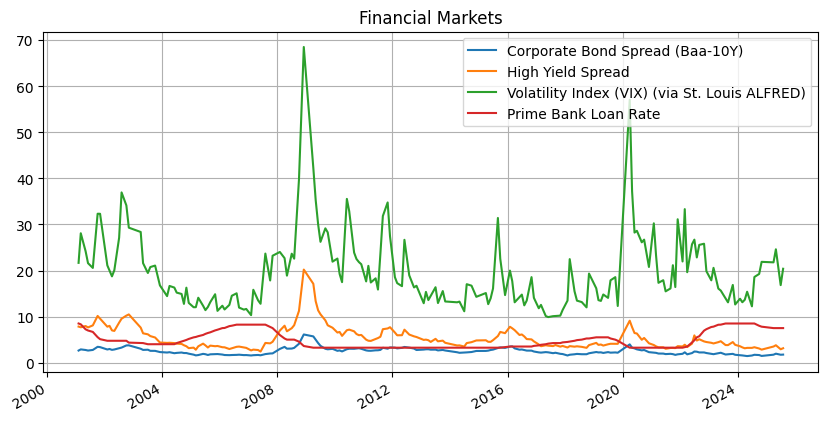

            Corporate Bond Spread (Baa-10Y)  High Yield Spread  \
2001-01-01                              NaN                NaN   
2001-01-02                             2.99               9.36   
2001-01-03                             2.83               9.13   
2001-01-04                             2.91               9.11   
2001-01-05                             2.99               9.12   
...                                     ...                ...   
2025-10-10                             1.72               3.18   
2025-10-13                              NaN               3.18   
2025-10-14                             1.71               3.11   
2025-10-15                             1.68               2.95   
2025-10-16                             1.71               3.04   

            Volatility Index (VIX) (via St. Louis ALFRED)  \
2001-01-01                                            NaN   
2001-01-02                                          29.99   
2001-01-03              

In [25]:
series = {
    #'S&P 500 Index':	'SP500',
'Corporate Bond Spread (Baa-10Y)':	'BAA10Y',
'High Yield Spread':	'BAMLH0A0HYM2',
'Volatility Index (VIX) (via St. Louis ALFRED)':	'VIXCLS',
'Prime Bank Loan Rate': 'MPRIME',
}
bank_data = pd.DataFrame({name: fred.get_series(id, observation_start='2001-01-01') for name, id in series.items()})

# Plot example: inflation and unemployment
bank_data.dropna().plot(
    figsize=(10, 5), title="Financial Markets"
)
plt.grid(True)
plt.show()
print(bank_data)

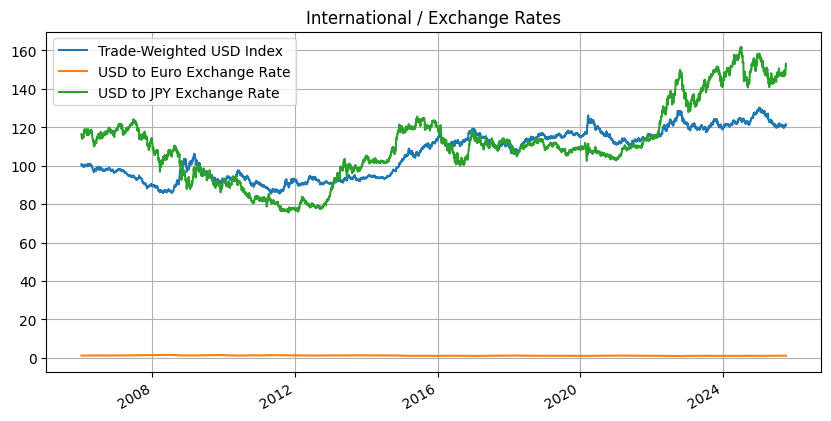

            Trade-Weighted USD Index  USD to Euro Exchange Rate  \
2000-01-03                       NaN                     1.0155   
2000-01-04                       NaN                     1.0309   
2000-01-05                       NaN                     1.0335   
2000-01-06                       NaN                     1.0324   
2000-01-07                       NaN                     1.0294   
...                              ...                        ...   
2025-10-06                  120.7028                     1.1707   
2025-10-07                  120.9097                     1.1674   
2025-10-08                  121.1884                     1.1606   
2025-10-09                  121.4965                     1.1559   
2025-10-10                  121.5217                     1.1613   

            USD to JPY Exchange Rate  
2000-01-03                    101.70  
2000-01-04                    103.09  
2000-01-05                    103.77  
2000-01-06                    105.19  


In [26]:
series = {
'Trade-Weighted USD Index':	'DTWEXBGS',
'USD to Euro Exchange Rate':	'DEXUSEU',
'USD to JPY Exchange Rate':	'DEXJPUS',
#'Foreign Exchange Reserves (China)':	'TRESEGUSM052N',
}
exchange_data = pd.DataFrame({name: fred.get_series(id, observation_start='2000-01-01') for name, id in series.items()})

# Plot example: inflation and unemployment
exchange_data.dropna().plot(
    figsize=(10, 5), title="International / Exchange Rates"
)
plt.grid(True)
plt.show()
print(exchange_data)

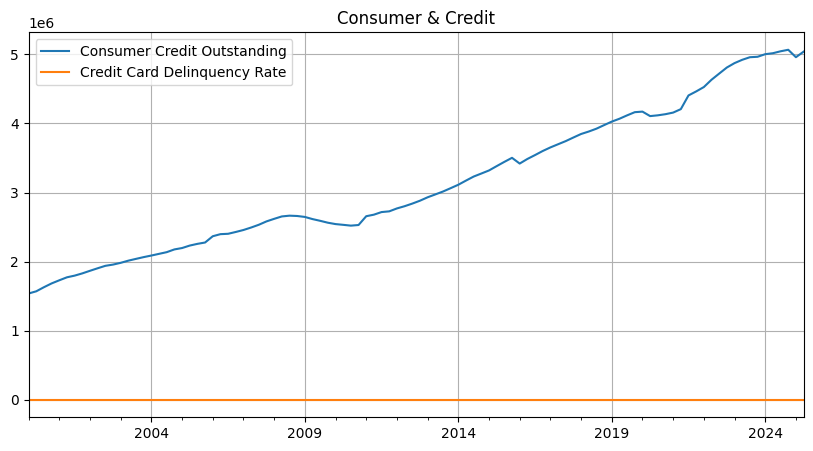

            Consumer Credit Outstanding  Credit Card Delinquency Rate
2000-01-01                   1538520.18                          4.43
2000-02-01                   1549185.29                           NaN
2000-03-01                   1561450.69                           NaN
2000-04-01                   1570527.74                          4.51
2000-05-01                   1583507.92                           NaN
...                                 ...                           ...
2025-04-01                   5039565.41                          3.05
2025-05-01                   5047404.95                           NaN
2025-06-01                   5042750.99                           NaN
2025-07-01                   5060804.10                           NaN
2025-08-01                   5061167.32                           NaN

[308 rows x 2 columns]


In [27]:
series = {
'Consumer Credit Outstanding':	'TOTALSL',
'Credit Card Delinquency Rate':	'DRCCLACBS',
#'Household Debt to GDP':	'HDTGDPUSQ163N',
}
debt_data = pd.DataFrame({name: fred.get_series(id, observation_start='2000-01-01') for name, id in series.items()})

# Plot example: inflation and unemployment
debt_data.dropna().plot(
    figsize=(10, 5), title="Consumer & Credit"
)
plt.grid(True)
plt.show()
print(debt_data)

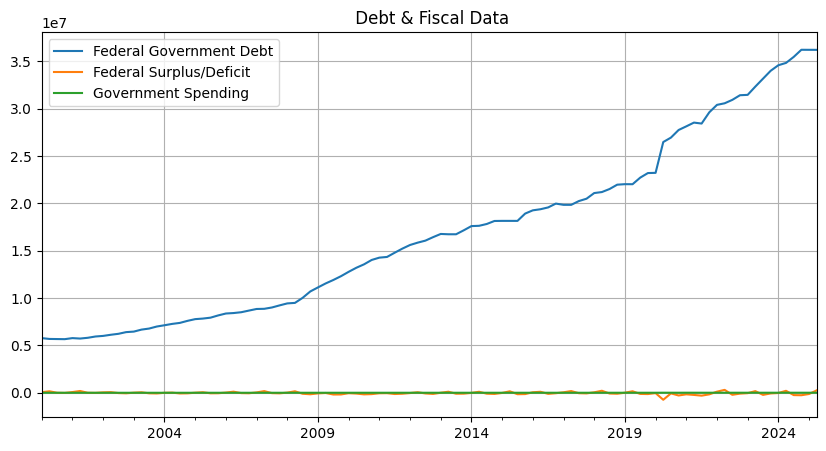

            Federal Government Debt  Federal Surplus/Deficit  \
2000-01-01                5773392.0             62152.000000   
2000-02-01                      NaN            -41734.000000   
2000-03-01                      NaN            -35380.000000   
2000-04-01                5685938.0            159497.000000   
2000-05-01                      NaN             -3611.000000   
...                             ...                      ...   
2025-04-01               36211469.0            258399.949115   
2025-05-01                      NaN           -316003.761189   
2025-06-01                      NaN             27010.022078   
2025-07-01                      NaN           -291142.660288   
2025-08-01                      NaN           -344791.891858   

            Government Spending  
2000-01-01             1866.308  
2000-02-01                  NaN  
2000-03-01                  NaN  
2000-04-01             1908.645  
2000-05-01                  NaN  
...                        

In [28]:
series = {
'Federal Government Debt':	'GFDEBTN',
#'Debt to GDP Ratio':	'GFDGDPA188S',
'Federal Surplus/Deficit':	'MTSDS133FMS',
'Government Spending':	'FGEXPND',
}
federal_data = pd.DataFrame({name: fred.get_series(id, observation_start='2000-01-01') for name, id in series.items()})

# Plot example: inflation and unemployment
federal_data.dropna().plot(
    figsize=(10, 5), title=" Debt & Fiscal Data"
)
plt.grid(True)
plt.show()
print(federal_data)

In [29]:
import pandas as pd

def to_monthly(df):
    """Resample to monthly frequency, forward-fill missing values, ensure DatetimeIndex."""
    df = df.copy()
    df.index = pd.to_datetime(df.index)           # ensure datetime
    df = df.resample('BMS').ffill()                 # monthly forward fill
    df = df.loc[~df.index.duplicated()]           # remove any duplicates
    return df.dropna()

datasets = {
    #'yield_10y': yield_10y,
    'macro_data': macro_data,
    'yield_data': yield_data,
    #'federal_data': federal_data,
    #'bank_data': bank_data,
    #'debt_data': debt_data,
    'consumer_data': consumer_data,
    'exchange_data': exchange_data
}
for name, df in datasets.items():
    df.index = pd.to_datetime(df.index)

monthly_data = {k: to_monthly(v) for k, v in datasets.items()}
all_data = pd.concat(monthly_data.values(), axis = 1)
print(all_data.columns)


Index(['10-Year Treasury Yield', '2-Year Treasury Yield',
       '3-month Treasury Yield', 'CPI (All Urban Consumers)', 'Core CPI',
       'PPI (Producer Price Index)', 'Core PCE', 'Import Price Index',
       'Trade-Weighted USD Index', 'USD to Euro Exchange Rate',
       'USD to JPY Exchange Rate'],
      dtype='object')


In [30]:
all_data = all_data

change_data = all_data.pct_change().replace([np.inf, -np.inf], np.nan).dropna()


/var/folders/6g/8lpphcyj6zz6mrxswq4gltjr0000gn/T/ipykernel_1473/1059370287.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  change_data = all_data.pct_change().replace([np.inf, -np.inf], np.nan).dropna()


In [31]:
maxs = {}
mins = {}
for column in change_data.columns:
    if column != "x":
        maxs[column] = np.max(np.abs(change_data[column]))
    else:
        maxs[column] = 1.0
print(maxs, mins)

{'10-Year Treasury Yield': np.float64(0.4363636363636364), '2-Year Treasury Yield': np.float64(0.8625954198473282), '3-month Treasury Yield': np.float64(7.0), 'CPI (All Urban Consumers)': np.float64(0.017705477084725474), 'Core CPI': np.float64(0.008005069017472666), 'PPI (Producer Price Index)': np.float64(0.053326561706450004), 'Core PCE': np.float64(0.0059189291399524), 'Import Price Index': np.float64(0.13731343283582098), 'Trade-Weighted USD Index': np.float64(0.0748397487866308), 'USD to Euro Exchange Rate': np.float64(0.09693582578531512), 'USD to JPY Exchange Rate': np.float64(0.12524319066147882)} {}


In [32]:
import yfinance as yf

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TLT', 'IEF', 'SHY', 'BND', "GC=F", "SI=F", "HG=F"]
data = yf.download(tickers, start='2001-01-01', end='2025-01-01')["Close"]
returns = data.pct_change().dropna()
month_data = data.resample("BMS").first()
month_returns = month_data.pct_change().dropna()
week_data = data.resample("W").first()
week_returns = week_data.pct_change().dropna()


[*********************100%***********************]  11 of 11 completed

11 Failed downloads:
['GOOGL', 'SHY', 'TLT', 'AMZN', 'SI=F', 'AAPL', 'HG=F', 'IEF', 'GC=F', 'MSFT', 'BND']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


/Users/aimaraguadoberasaluce/Desktop/Financial/Machine-Learning-in-Finance/openbb_env/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/aimaraguadoberasaluce/Desktop/Financial/Machine-Learning-in-Finance/openbb_env/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


<Axes: xlabel='Ticker', ylabel='Ticker'>

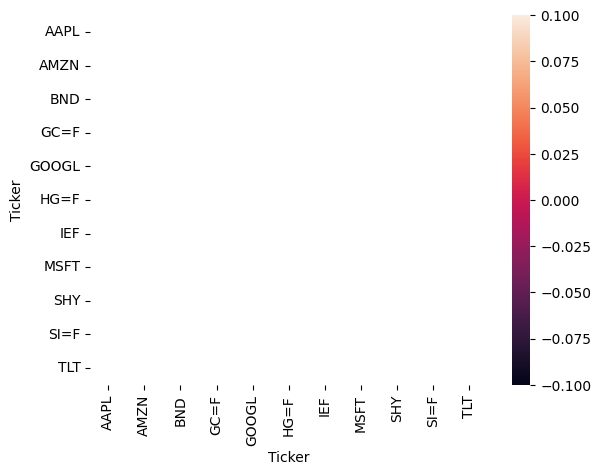

In [33]:
sns.heatmap(returns.corr(), annot=True)

/Users/aimaraguadoberasaluce/Desktop/Financial/Machine-Learning-in-Finance/openbb_env/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/aimaraguadoberasaluce/Desktop/Financial/Machine-Learning-in-Finance/openbb_env/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


<Axes: >

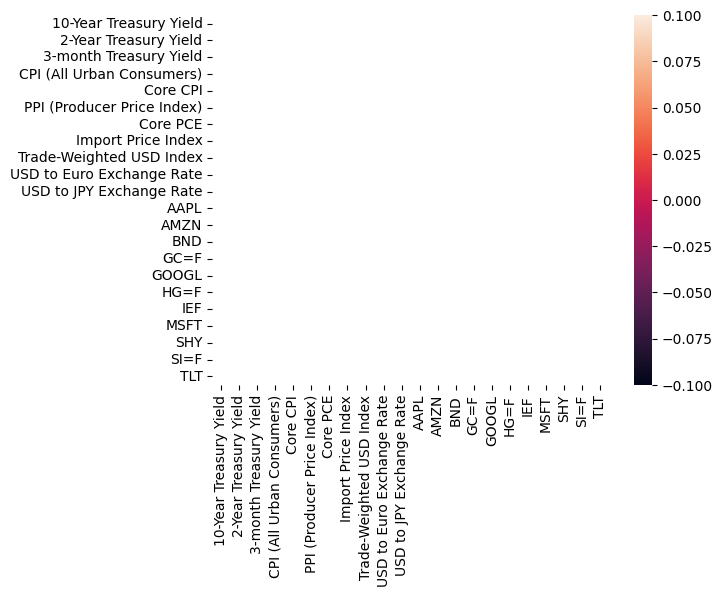

In [34]:
whole_data = pd.concat([change_data, month_returns], axis = 1)
whole_data = whole_data.dropna()
sns.heatmap(whole_data.corr(), annot=True)

In [35]:
print(whole_data.head())
XX = whole_data[['10-Year Treasury Yield', '2-Year Treasury Yield',
       '3-month Treasury Yield', 'CPI (All Urban Consumers)', 'Core CPI',
       'PPI (Producer Price Index)', 'Core PCE', 'Import Price Index',
       'Trade-Weighted USD Index', 'USD to Euro Exchange Rate',
       'USD to JPY Exchange Rate']]
whole_data.isna().sum()

Empty DataFrame
Columns: [10-Year Treasury Yield, 2-Year Treasury Yield, 3-month Treasury Yield, CPI (All Urban Consumers), Core CPI, PPI (Producer Price Index), Core PCE, Import Price Index, Trade-Weighted USD Index, USD to Euro Exchange Rate, USD to JPY Exchange Rate, AAPL, AMZN, BND, GC=F, GOOGL, HG=F, IEF, MSFT, SHY, SI=F, TLT]
Index: []

[0 rows x 22 columns]


10-Year Treasury Yield        0
2-Year Treasury Yield         0
3-month Treasury Yield        0
CPI (All Urban Consumers)     0
Core CPI                      0
PPI (Producer Price Index)    0
Core PCE                      0
Import Price Index            0
Trade-Weighted USD Index      0
USD to Euro Exchange Rate     0
USD to JPY Exchange Rate      0
AAPL                          0
AMZN                          0
BND                           0
GC=F                          0
GOOGL                         0
HG=F                          0
IEF                           0
MSFT                          0
SHY                           0
SI=F                          0
TLT                           0
dtype: int64

In [36]:
import statsmodels.api as sm
results = {}
for asset in month_returns:
    Y = whole_data[asset]
    X = sm.add_constant(XX)
    model = sm.OLS(Y, X, missing='drop').fit()
    results[asset] = model.params
betas = pd.DataFrame(results).T
betas

ValueError: zero-size array to reduction operation maximum which has no identity

In [94]:
print(np.max(betas))

7.172955536282184


In [65]:
def calculate_returns(returns, returns_period, period):
    covariance = {}
    for i in returns_period.index:
        rtd_index = returns.index
        if period =="month":
            mask = (rtd_index.month == i.month) & (rtd_index.year == i.year)
        elif period == "week":
            mask = mask = ((rtd_index.isocalendar().week == i.isocalendar().week) &(rtd_index.isocalendar().year == i.isocalendar().year))
        elif period == "quarter":
            mask = (rtd_index.quarter == i.quarter) & (rtd_index.year == i.year)
        covariance[i] = returns[mask].cov()
    portfolio_returns = {}
    portfolio_volatility = {}
    portfolio_weights = {}
    for date in covariance.keys():
        cov = covariance[date]
        for k in range(10000):
            weights = np.random.random(returns.shape[1])
            weights = weights/np.sum(weights)
            returnss = np.dot(weights, returns_period.loc[date])
            volatility = np.sqrt(np.dot(weights.T,np.dot(cov, weights)))
            portfolio_returns.setdefault(date,[]).append(returnss)
            portfolio_volatility.setdefault(date,[]).append(volatility)
            portfolio_weights.setdefault(date,[]).append(weights)
    sharpe_ratio = {}
    max_sharpe = {}
    vols = {}
    min_vol = {}
    for date in covariance.keys():
        for i, (ret, vol) in enumerate(zip(portfolio_returns[date], portfolio_volatility[date])):
            sharpe_ratio.setdefault(date, []).append(ret / vol)
            vols.setdefault(date, []).append(vol)
        max_sharpe[date] = np.argmax(sharpe_ratio[date])
        min_vol[date] = np.argmin(vols[date])
    dates = sorted(covariance.keys())

    strategy_returns = []
    strategy_returns2 = []

    for i in range(len(dates) - 1):
        current_date = dates[i]
        next_date = dates[i + 1]

        weights = portfolio_weights[current_date][min_vol[current_date]]
        weights2 = portfolio_weights[current_date][max_sharpe[current_date]]

        returns_next = returns_period.loc[next_date] 

        port_return = np.dot(weights, returns_next)
        port_return2 = np.dot(weights2, returns_next)
        strategy_returns.append(port_return)
        strategy_returns2.append(port_return2)

    strategy_returns = pd.Series(strategy_returns, index=dates[1:])
    strategy_returns2 = pd.Series(strategy_returns2, index=dates[1:])

    cumulative_returns = (1 + strategy_returns).cumprod()

    total_return = cumulative_returns.iloc[-1] - 1

    cumulative_returns2 = (1 + strategy_returns2).cumprod()

    total_return2 = cumulative_returns2.iloc[-1] - 1

    print(f"Total return from strategy of minimum volatility: {total_return:.2%}")
    print(f"Total return from strategy of max sharpe: {total_return2:.2%}")
    #
    # including tax costs
    #
    dates = sorted(covariance.keys())

    strategy_returns = []
    strategy_returns2 = []
    weightss = []

    for i in range(len(dates) - 1):
        current_date = dates[i]
        next_date = dates[i + 1]

        weights = portfolio_weights[current_date][min_vol[current_date]]
        weightss.append(weights)
        weights2 = portfolio_weights[current_date][max_sharpe[current_date]]
        returns_next = returns_period.loc[next_date] 
        returns_next = np.where(returns_next>0.0, returns_next*0.79, returns_next)

        port_return = np.dot(weights, returns_next)
        port_return2 = np.dot(weights2, returns_next)
        strategy_returns.append(port_return)
        strategy_returns2.append(port_return2)

    strategy_returns = pd.Series(strategy_returns, index=dates[1:])
    strategy_returns2 = pd.Series(strategy_returns2, index=dates[1:])

    cumulative_returns = (1 + strategy_returns).cumprod()

    total_return = cumulative_returns.iloc[-1] - 1

    cumulative_returns2 = (1 + strategy_returns2).cumprod()

    total_return2 = cumulative_returns2.iloc[-1] - 1

    print(f"Total return from strategy of minimum volatility taking taxes into account: {total_return:.2%}")
    print(f"Total return from strategy of max sharpe taking taxes into account: {total_return2:.2%}")
    return strategy_returns, strategy_returns2, max_sharpe, min_vol, weights, weightss

In [67]:
ret1, ret2, max_s, min_vol, weights, weightss = calculate_returns(returns, month_returns, "month")

IndexError: single positional indexer is out-of-bounds

In [46]:
print(weightss)

NameError: name 'weightss' is not defined

In [97]:
# Ensure betas have a constant column named 'const'
if 'const' not in betas.columns:
    betas = betas.rename(columns={'Intercept': 'const'})

# Build scenarios
X_pos = sm.add_constant(pd.DataFrame([maxs]))
X_neg = sm.add_constant(pd.DataFrame([{col: -val for col, val in maxs.items()}]))

# Align columns
X_pos = X_pos.reindex(columns=betas.columns, fill_value=0)
X_neg = X_neg.reindex(columns=betas.columns, fill_value=0)

# Predict
pred_pos = (X_pos @ betas.T).squeeze()
pred_neg = (X_neg @ betas.T).squeeze()
print(pred_pos, pred_neg)


AAPL    -0.289744
AMZN     0.008612
BND     -0.081940
GC=F     0.028576
GOOGL    0.052642
HG=F    -0.014170
IEF     -0.087019
MSFT    -0.094910
SHY     -0.017436
SI=F     0.112385
TLT     -0.176072
Name: 0, dtype: float64 AAPL     0.289744
AMZN    -0.008612
BND      0.081940
GC=F    -0.028576
GOOGL   -0.052642
HG=F     0.014170
IEF      0.087019
MSFT     0.094910
SHY      0.017436
SI=F    -0.112385
TLT      0.176072
Name: 0, dtype: float64


In [98]:
port_pos = (pred_pos * weights).sum()
port_neg = (pred_neg * weights).sum()
print(port_pos, port_neg)

-0.048283075397916625 0.048283075397916625


In [99]:
values = []
for i in range(10000):
    maxs = {}
    mins = {}
    for column in change_data.columns:
        value = np.random.uniform(0,1)
        if value > 0.5:
            maxs[column] = np.max(change_data[column])
        else:
            maxs[column] = -1.0*np.max(change_data[column])
    X_pos = sm.add_constant(pd.DataFrame([maxs]))
    X_pos = X_pos.reindex(columns=betas.columns, fill_value=0)

    # Predict
    pred_pos = (X_pos @ betas.T).squeeze()
    port_pos = (pred_pos * weights).sum()
    values.append(port_pos)

            



In [100]:
alpha = 0.05
var = np.quantile(values, alpha)
values = np.array(values)
expected_var = values[values <= var].mean()
print("VaR:", var, "Expected VaR:", expected_var)


VaR: -0.10445955223744521 Expected VaR: -0.11830569690033256


(array([ 283.,  718., 1205., 1352., 1494., 1512., 1275., 1182.,  699.,
         280.]),
 array([-0.14295981, -0.11436785, -0.08577589, -0.05718392, -0.02859196,
         0.        ,  0.02859196,  0.05718392,  0.08577589,  0.11436785,
         0.14295981]),
 <BarContainer object of 10 artists>)

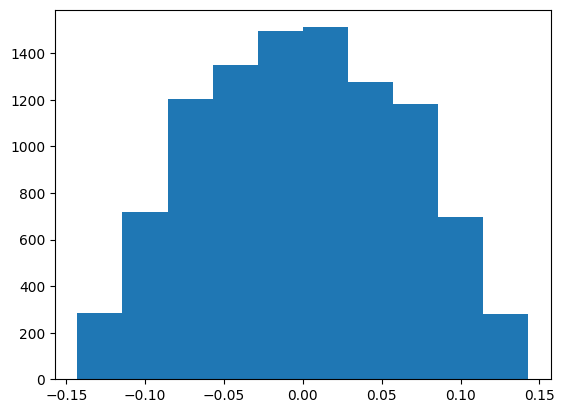

In [101]:
plt.hist(values)


(np.float64(-0.0007808607759386193), np.float64(0.0638963097057081))
-0.1429598092507211


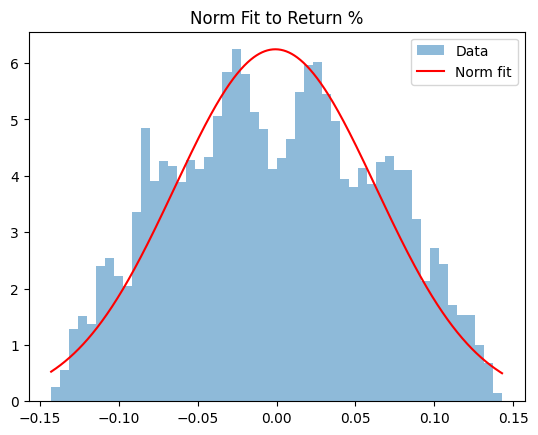

In [102]:
params_norm = norm.fit(values)
print(params_norm)
print(min(values))

x = np.linspace(values.min(), values.max(), 1000)
pdf = norm.pdf(x, *params_norm)

plt.hist(values, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r-', label="Norm fit")
plt.legend()
plt.title("Norm Fit to Return %")
plt.show()

In [103]:
from scipy.stats import kstest, norm

mu, sigma = params_norm
ks_stat, ks_pvalue = kstest(values, 'norm', args=(mu, sigma))

print(f"K–S statistic: {ks_stat:.4f}")
print(f"P-value: {ks_pvalue:.4f}")


K–S statistic: 0.0384
P-value: 0.0000


In [104]:
from scipy.stats import anderson

result = anderson(values, dist='norm')
print(f"Anderson–Darling statistic: {result.statistic:.4f}")
print("Critical values:", result.critical_values)
print("Significance levels:", result.significance_level)


Anderson–Darling statistic: 34.0907
Critical values: [0.576 0.656 0.787 0.918 1.092]
Significance levels: [15.  10.   5.   2.5  1. ]


In [105]:
from scipy.stats import norm, t, laplace
import numpy as np

# Fit Normal
params_norm = norm.fit(values)
loglik_norm = np.sum(norm.logpdf(values, *params_norm))

# Fit Student-t
params_t = t.fit(values)
loglik_t = np.sum(t.logpdf(values, *params_t))

# Fit Laplace
params_laplace = laplace.fit(values)
loglik_laplace = np.sum(laplace.logpdf(values, *params_laplace))

# Compare AIC
def AIC(loglik, k, n):
    return 2*k - 2*loglik

n = len(values)
aic_norm = AIC(loglik_norm, 2, n)
aic_t = AIC(loglik_t, 3, n)         # t has 3 params (df, loc, scale)
aic_laplace = AIC(loglik_laplace, 2, n)

print("AIC comparison:")
print(f"Normal:  {aic_norm:.2f}")
print(f"t-dist:  {aic_t:.2f}")
print(f"Laplace: {aic_laplace:.2f}")


AIC comparison:
Normal:  -26627.10
t-dist:  -26625.10
Laplace: -24614.26


In [106]:
from scipy.stats import t
import numpy as np

# Fit the t-distribution to your returns
params_t = t.fit(values)
df, loc, scale = params_t
print(f"df={df:.2f}, loc={loc:.5f}, scale={scale:.5f}")
alpha = 0.05
var_t = t.ppf(alpha, df, loc=loc, scale=scale)
print(f"5% VaR (t-dist): {var_t:.5f}")
# Numerical expected shortfall
x = np.linspace(t.ppf(0.0001, df, loc, scale),
                t.ppf(0.9999, df, loc, scale), 100000)
pdf = t.pdf(x, df, loc, scale)
expected_var_t = np.mean(x[x <= var_t])

print(f"Expected VaR (t-dist): {expected_var_t:.5f}")


df=172775590.28, loc=-0.00078, scale=0.06390
5% VaR (t-dist): -0.10588
Expected VaR (t-dist): -0.17215


In [107]:
ret1, ret2, max_s, min_vol, weights, weightss2 =calculate_returns(returns[['AAPL', 'MSFT', 'GOOGL', 'AMZN']], month_returns[['AAPL', 'MSFT', 'GOOGL', 'AMZN']], "month")

Total return from strategy of minimum volatility: 4792.97%
Total return from strategy of max sharpe: 7323.87%
Total return from strategy of minimum volatility taking taxes into account: 812.13%
Total return from strategy of max sharpe taking taxes into account: 1074.67%


In [108]:
import statsmodels.api as sm
XX = whole_data[['10-Year Treasury Yield', '2-Year Treasury Yield',
       '3-month Treasury Yield', 'CPI (All Urban Consumers)', 'Core CPI',
       'PPI (Producer Price Index)', 'Core PCE', 'Import Price Index',
       'Trade-Weighted USD Index', 'USD to Euro Exchange Rate',
       'USD to JPY Exchange Rate']]
results2 = {}
for asset in month_returns[['AAPL', 'MSFT', 'GOOGL', 'AMZN']]:
    Y = whole_data[asset]
    X = sm.add_constant(XX)
    model = sm.OLS(Y, X, missing='drop').fit()
    results2[asset] = model.params
betas2 = pd.DataFrame(results2).T
betas2

,const,10-Year Treasury Yield,2-Year Treasury Yield,3-month Treasury Yield,CPI (All Urban Consumers),Core CPI,PPI (Producer Price Index),Core PCE,Import Price Index,Trade-Weighted USD Index,USD to Euro Exchange Rate,USD to JPY Exchange Rate
AAPL,0.037556,-0.190670,0.103079,0.004544,-2.221415,-6.603639,1.276453,4.127871,-0.213891,-3.191546,-0.892883,0.217187
MSFT,0.022090,-0.132033,0.055136,0.006128,-3.867792,-0.116240,0.649965,2.061720,-0.143278,-2.201010,-0.034809,0.659255
GOOGL,0.019833,0.033416,0.010254,0.018381,1.050073,-0.685835,0.671673,-2.889554,-0.151688,-1.737260,0.063745,0.106955
AMZN,0.043767,-0.099561,0.087081,0.015996,4.258190,-6.619064,-0.332978,-7.779364,0.192551,-2.012052,-0.024210,0.262325


In [109]:
# Ensure betas have a constant column named 'const'
if 'const' not in betas2.columns:
    betas2 = betas2.rename(columns={'Intercept': 'const'})

values = []
for i in range(10000):
    maxs = {}
    mins = {}
    for column in change_data.columns:
        value = np.random.uniform(0,1)
        if value > 0.5:
            maxs[column] = np.max(change_data[column])
        else:
            maxs[column] = -1.0*np.max(change_data[column])
    X_pos = sm.add_constant(pd.DataFrame([maxs]))
    X_pos = X_pos.reindex(columns=betas2.columns, fill_value=0)

    # Predict
    pred_pos = (X_pos @ betas2.T).squeeze()
    port_pos = (pred_pos * weights).sum()
    values.append(port_pos)

In [110]:
alpha = 0.05
var = np.quantile(values, alpha)
values = np.array(values)
expected_var = values[values <= var].mean()
print("VaR:", var, "Expected VaR:", expected_var)

VaR: -0.3976051520625629 Expected VaR: -0.4546280290488983


(array([  72.,  565., 1385., 1635., 1295., 1343., 1667., 1376.,  563.,
          99.]),
 array([-0.63264223, -0.50611378, -0.37958534, -0.25305689, -0.12652845,
         0.        ,  0.12652845,  0.25305689,  0.37958534,  0.50611378,
         0.63264223]),
 <BarContainer object of 10 artists>)

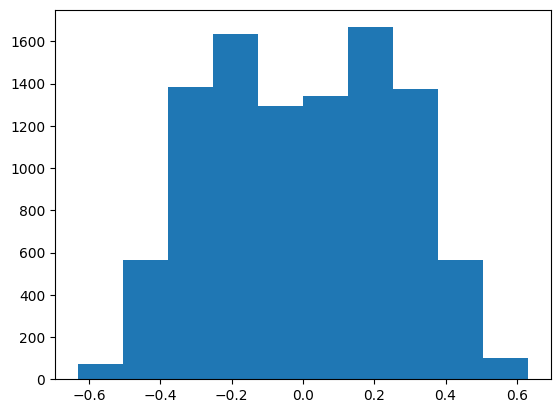

In [111]:
plt.hist(values)

(np.float64(0.0019902909337178747), np.float64(0.2577124696402576))
-0.6326422296445762


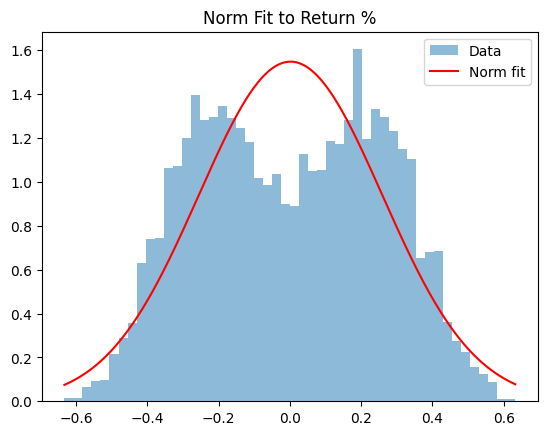

In [112]:
params_norm = norm.fit(values)
print(params_norm)
print(min(values))

x = np.linspace(values.min(), values.max(), 1000)
pdf = norm.pdf(x, *params_norm)

plt.hist(values, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r-', label="Norm fit")
plt.legend()
plt.title("Norm Fit to Return %")
plt.show()

In [113]:
mu, sigma = params_norm
ks_stat, ks_pvalue = kstest(values, 'norm', args=(mu, sigma))

print(f"K–S statistic: {ks_stat:.4f}")
print(f"P-value: {ks_pvalue:.4f}")

K–S statistic: 0.0626
P-value: 0.0000


In [114]:
# Fit the t-distribution to your returns
params_t = t.fit(values)
df, loc, scale = params_t
print(f"df={df:.2f}, loc={loc:.5f}, scale={scale:.5f}")
alpha = 0.05
var_t = t.ppf(alpha, df, loc=loc, scale=scale)
print(f"5% VaR (t-dist): {var_t:.5f}")
# Numerical expected shortfall
x = np.linspace(t.ppf(0.0001, df, loc, scale),
                t.ppf(0.9999, df, loc, scale), 100000)
pdf = t.pdf(x, df, loc, scale)
expected_var_t = np.mean(x[x <= var_t])

print(f"Expected VaR (t-dist): {expected_var_t:.5f}")

df=6032818455.74, loc=0.00199, scale=0.25771
5% VaR (t-dist): -0.42191
Expected VaR (t-dist): -0.68918
